<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/Python-Notebook-Banners/Code_challenge.png"  style="display: block; margin-left: auto; margin-right: auto;";/>
</div>

# K-means and hierarchical clustering MCQ
© ExploreAI Academy

In this MCQ, we will review and assess our understanding of the core concepts of k-means and hierarchical clustering.

## Learning objectives

By the end of this MCQ, you should be able to:
* Find the optimal number of clusters for a k-means clustering model.
* Apply the Kmeans clustering algorithm and evaluate its quality.
* Find the optimal number of clusters using hierachical clustering.
* Implement agglomerative hierarchical clustering.

## Introduction

The dataset contains information about mall customers, including their gender, age, annual income (in thousands of dollars), and spending score. Each row in the dataset represents a unique customer, identified by a CustomerID. The data was collected from a survey for marketing or customer segmentation purposes.

The primary objective of this analysis is to segment the customers based on their **annual income and spending scores** using K-means and hierarchical clustering. We aim to identify distinct groups of customers with similar spending behaviours and income levels. This segmentation can help in targeted marketing strategies, understanding customer preferences, and improving overall customer satisfaction and retention.

⚠️**Note**: This notebook is running Python version 3.11.14. To ensure that our results are consistent, please switch to this version. Please also note that the order of answers in the MCQ test itself might differ from what is presented here.

In [1]:
import pandas as pd
data = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/mall_customers.csv', index_col=0)
data

,Genre,Age,Annual_Income_(k$),Spending_Score
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40
...,...,...,...,...
196,Female,35,120,79
197,Female,45,126,28
198,Male,32,126,74


## Questions
### Question 1

Before we dive in, it’s crucial to acquaint ourselves with the dataset through exploration and preliminary analysis by understanding its characteristics.
 
Print the descriptive statistics of our dataset.
True or false. The `Spending_Score` is a number from 1 - 50.

#### Options:

* True
* False


In [2]:
#Your code here
# Print descriptive statistics
data.describe()


,Age,Annual_Income_(k$),Spending_Score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


### Question 2
What is the total number of observations in this dataset?

#### Options:
* 100
* 150
* 200
* 250
 


In [3]:
# Display the basic information about the dataset
print(data.info())

# Count the total number of observations
total_observations = data.shape[0]
print(f'Total number of observations: {total_observations}')

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Genre               200 non-null    object
 1   Age                 200 non-null    int64 
 2   Annual_Income_(k$)  200 non-null    int64 
 3   Spending_Score      200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 7.8+ KB
None
Total number of observations: 200


### Question 3
Next, we need to check if the data contains any null values because missing values can disrupt the modelling process by causing errors or biases in our analysis.

Write code that will check if our dataset contains any null values. If so, fill them with zero's.
True or false. Our dataset contains no null values.

#### Options:

* True
* False


In [4]:
#Your code here
# Step 1: Check for null values
null_values = data.isnull().sum()
print("Null values before filling:")
print(null_values)

# Step 2: Fill null values with zeros
data_filled = data.fillna(0)

# Step 3: Verify no null values remain
null_values_after = data_filled.isnull().sum()
print("Null values after filling:")
print(null_values_after)

# Determine if the dataset initially contained no null values
contains_null_values = null_values.sum() > 0
print(f"Our dataset contains null values: {contains_null_values}")

# Answer
if contains_null_values:
    answer = "False"
else:
    answer = "True"

print(f"Answer: {answer}")

Null values before filling:
Genre                 0
Age                   0
Annual_Income_(k$)    0
Spending_Score        0
dtype: int64
Null values after filling:
Genre                 0
Age                   0
Annual_Income_(k$)    0
Spending_Score        0
dtype: int64
Our dataset contains null values: False
Answer: True


### Question 4 
Since we are interested in segmenting our customers based on their **annual income and spending score**, let's visualise the relationship between this pair.

Generate a scatter plot showing the relationship between annual income and spending score for each customer in the dataset.

What insights can be inferred from the scatter plot?

#### Options:

* The data points exhibit a uniform distribution across the grid.
* There are visible clusters forming, particularly in the center of the plot.
* Points are evenly spread, indicating no discernible patterns or correlations.
* There is no relationship between annual income and spending score.



C:\Users\moses_y\AppData\Local\Temp\ipykernel_27960\880921630.py:14: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


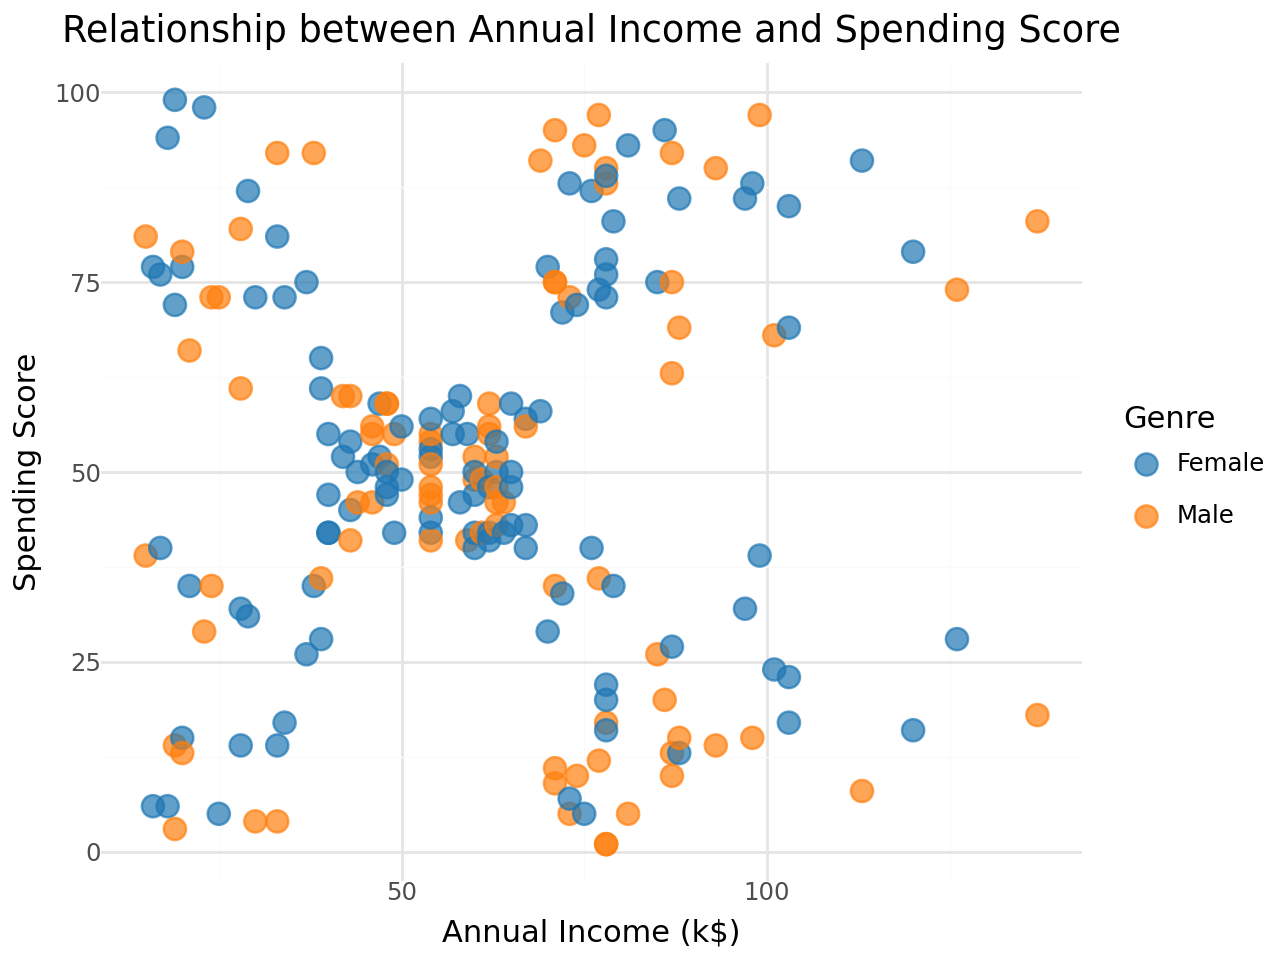

In [11]:
import pandas as pd
from plotnine import ggplot, aes, geom_point, theme_minimal, labs, scale_color_manual

# Load the dataset
#data = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/mall_customers.csv', index_col=0)

# Generate a scatter plot using plotnine (ggplot2 for Python)
plot = (ggplot(data, aes(x='Annual_Income_(k$)', y='Spending_Score', color='Genre')) +
        geom_point(size=4, alpha=0.7) +
        theme_minimal() +
        labs(title='Relationship between Annual Income and Spending Score',
             x='Annual Income (k$)', y='Spending Score', color='Genre') +
        scale_color_manual(values=['#1f77b4', '#ff7f0e']))
print(plot)


In [12]:
import pandas as pd
import plotly.express as px

# Load the dataset
#data = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/mall_customers.csv', index_col=0)

# Generate an interactive scatter plot using Plotly
fig = px.scatter(data, x='Annual_Income_(k$)', y='Spending_Score', color='Genre',
                 title='Relationship between Annual Income and Spending Score',
                 labels={'Annual_Income_(k$)': 'Annual Income (k$)', 'Spending_Score': 'Spending Score'},
                 template='plotly_dark', size='Age', hover_data=['Age', 'Genre'])
fig.update_layout(title_font_size=20, legend_title_text='Genre', legend_title_font_size=14)
fig.show()


### Question 5
Before continuing our analysis, we need to scale our data to prevent attributes with larger magnitudes from dominating the distance calculations. 

The code below attempts to scale the data but it returns an error. 
Which of the following best explains why the provided code returns an error?

#### Options:


* The code fails because the MinMaxScaler requires the data to be in a specific range, and the provided data exceeds this range.

* The error occurs because the MinMaxScaler cannot handle missing values in the dataset.

* The code attempts to fit the MinMaxScaler on non-numeric data, resulting in a ValueError because the MinMaxScaler only works with numerical data.

* The code fails because the MinMaxScaler requires the input data to be a NumPy array, and the provided data is not in this format.

In [13]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X_scaled = ms.fit_transform(data)

ValueError: could not convert string to float: 'Male'

### Question 6

Let's initiate our cluster analysis by selecting the features for segmentation. Given our focus on customer segmentation using their annual income and spending score, we'll designate the `Annual_Income_(k$)` and `Spending_Score` columns as the features for clustering, assigning them to the variable `X`.

Following feature selection, let's scale our data using the MinMaxScaler as attempted in the previous question and implement the K-Means clustering algorithm on the scaled dataset, opting for **5** clusters based on an initial analysis of our scatter plot.

Following the application of the K-Means model using 5 clusters, which of the following code snippets will display the coordinates of the centroids representing the clusters identified by the algorithm?

#### Options:
* `print(kmeans.centroids_)`
* **`print(kmeans.cluster_centers_)`**
* `print(kmeans.cluster_centers)`
* `print(kmeans.centroids)`

In [14]:
#Your code here
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Load the dataset
#data = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/mall_customers.csv', index_col=0)

# Select the relevant features
X = data[['Annual_Income_(k$)', 'Spending_Score']]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Initialize K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)

# Fit the model to the scaled data
kmeans.fit(X_scaled)

# Predict the clusters for the data points
clusters = kmeans.predict(X_scaled)

# Display the coordinates of the centroids
print(kmeans.cluster_centers_)


[[0.32695811 0.49533888]
 [0.58638083 0.82783883]
 [0.08792846 0.79962894]
 [0.59631148 0.16921769]
 [0.08792846 0.19619666]]


### Question 7 
To build an accurate model, there are methods we can use to determine the optimal number of clusters to employ in our analysis.

Which of the following measures are **NOT** typically used to help us determine the best K value for our data?

#### Options:
* Within-cluster variation
* Between-cluster variation
* Outer-cluster variation
* The CH index

### Question 8

Let's determine the optimal k value. Use the `Elbow method`, with `WCSS`, to find the best K value for our dataset.

Based on the elbow method plot, which is the best K value for our data?

#### Options:
* 3 clusters
* 5 clusters
* 7 clusters
* 10 clusters

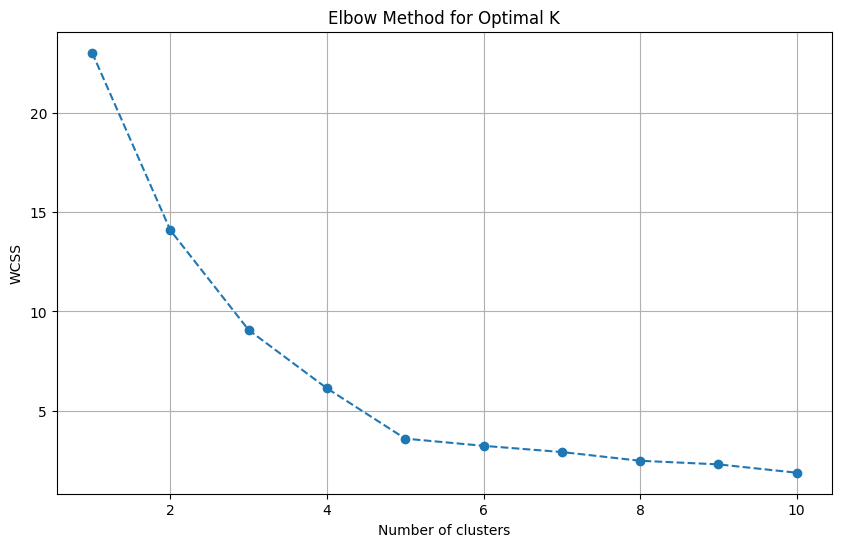

In [15]:
#Your code here
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# # Load the dataset
# data = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/mall_customers.csv', index_col=0)

# # Select the relevant features
# X = data[['Annual_Income_(k$)', 'Spending_Score']]

# # Initialize the MinMaxScaler
# scaler = MinMaxScaler()

# # Fit and transform the data
# X_scaled = scaler.fit_transform(X)

# Calculate WCSS for different number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


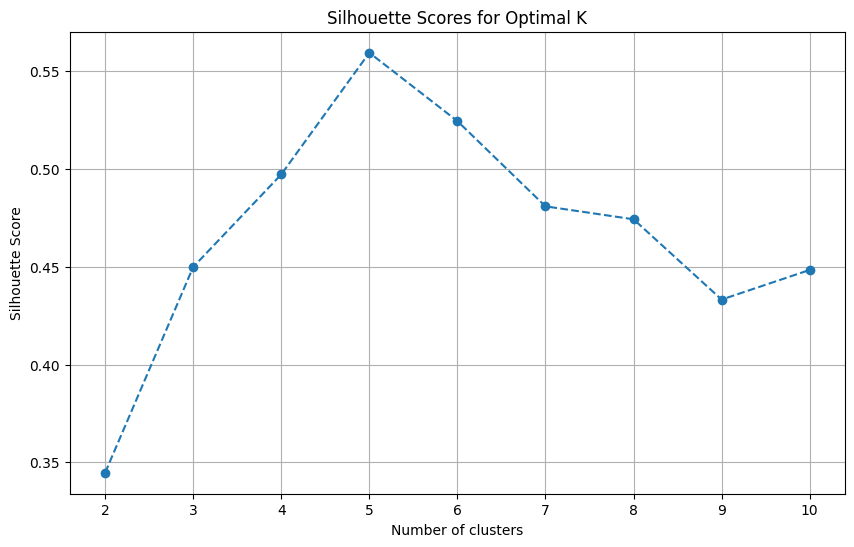

In [16]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Scores for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()


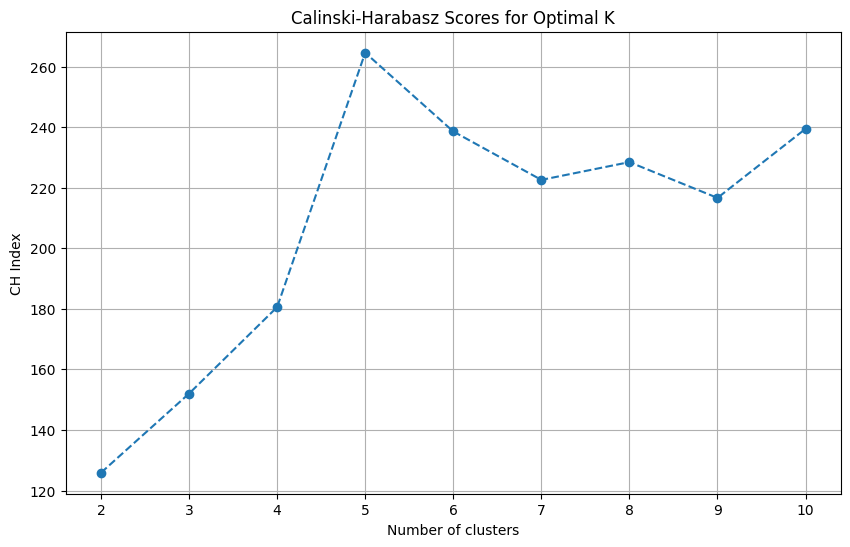

In [17]:
from sklearn.metrics import calinski_harabasz_score

ch_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    score = calinski_harabasz_score(X_scaled, kmeans.labels_)
    ch_scores.append(score)

# Plot CH Scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), ch_scores, marker='o', linestyle='--')
plt.title('Calinski-Harabasz Scores for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('CH Index')
plt.grid(True)
plt.show()


### Question 9
Let's evaluate the model's quality by computing its silhouette score.

Based on the results, what is the silhouette score for a k-means model with k=5 clusters?
#### Options: 
* 0.625
* 0.559
* 0.715
* 0.890

In [19]:
#Your code here
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load the dataset
data = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/mall_customers.csv', index_col=0)

# Select the relevant features
X = data[['Annual_Income_(k$)', 'Spending_Score']]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Initialize K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)

# Fit the model to the scaled data
kmeans.fit(X_scaled)

# Predict the clusters for the data points
clusters = kmeans.predict(X_scaled)

# Compute the silhouette score
silhouette_avg = silhouette_score(X_scaled, clusters)
print(f'Silhouette Score for k=5: {silhouette_avg}')


Silhouette Score for k=5: 0.5593469429051445


### Question 10
What does the resulting silhouette score indicate?

#### Options:

* It is quite bad because it is less than 10.
* It is good because it is greater than 0 and relatively close to 1.
* It is very bad because we want it to be closer to -1.
* The silhouette score does not really matter.

### Question 11

What is the next appropriate step after determining that the silhouette score for the optimal number of clusters, determined by the elbow method, is deemed unsatisfactory?

#### Options:
* Increase the number of clusters and recompute the silhouette score.
* Decrease the number of clusters and recompute the silhouette score.
* Ignore the silhouette score and proceed with the current clustering configuration.
* Use the silhouette score as input into decision-making when evaluating other clustering algorithms.

In [20]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load the dataset
data = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/mall_customers.csv', index_col=0)

# Select the relevant features
X = data[['Annual_Income_(k$)', 'Spending_Score']]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Iterate over a range of cluster numbers
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    clusters = kmeans.predict(X_scaled)
    score = silhouette_score(X_scaled, clusters)
    print(f'Silhouette Score for k={k}: {score}')


Silhouette Score for k=2: 0.3447138642257591
Silhouette Score for k=3: 0.4498539603795658
Silhouette Score for k=4: 0.4971506623868143
Silhouette Score for k=5: 0.5593469429051445
Silhouette Score for k=6: 0.5244046259750482
Silhouette Score for k=7: 0.48083628842905113
Silhouette Score for k=8: 0.47423530152553683
Silhouette Score for k=9: 0.4332042575649034
Silhouette Score for k=10: 0.44833378088523645


In [22]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=5)
agglo_clusters = agglo.fit_predict(X_scaled)
agglo_score = silhouette_score(X_scaled, agglo_clusters)
print(f'Agglomerative Clustering Silhouette Score: {agglo_score}')

# DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X_scaled)
# Handle case where DBSCAN finds only one cluster
if len(set(dbscan_clusters)) > 1:
    dbscan_score = silhouette_score(X_scaled, dbscan_clusters)
    print(f'DBSCAN Silhouette Score: {dbscan_score}')
else:
    print('DBSCAN did not find more than one cluster.')

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=5, random_state=42)
gmm_clusters = gmm.fit_predict(X_scaled)
gmm_score = silhouette_score(X_scaled, gmm_clusters)
print(f'Gaussian Mixture Model Silhouette Score: {gmm_score}')


Agglomerative Clustering Silhouette Score: 0.5582698727196419
DBSCAN did not find more than one cluster.
Gaussian Mixture Model Silhouette Score: 0.5601396671322825


### Question 12
Hierarchical clustering could be a natural next step for further analysis, especially considering the presence of the outliers and the potentially uneven cluster shapes observed in the KMeans model results. Hierarchical clustering can offer insights into the hierarchical structure of the data, potentially capturing nuances that KMeans might overlook.

Which of the following is a key difference between KMeans and Hierarchical clustering algorithms?

#### Options:
* Hierarchical Clustering forms spherical clusters around centroids. Each data point belongs to the cluster with the nearest centroid. In contrast, KMeans builds a hierarchy of clusters, starting with individual data points and gradually merging them into larger clusters based on proximity.
* Hierarchical clustering assumes clusters to be spherical and of equal size, which may not always reflect the true underlying structure of the data, whereas KMeans can capture clusters of arbitrary shapes and sizes, offering more flexibility in cluster formation.
* Hierarchical clustering does not require the number of clusters to be predefined. It produces a hierarchical tree of clusters, and the number of clusters can be determined after the clustering process, whereas KMeans requires the number of clusters (K) to be specified in advance.
* Hierarchical Clustering requires the number of clusters (K) to be specified in advance. In contrast, KMeans does not require the number of clusters to be predefined. It produces a hierarchical tree of clusters, and the number of clusters can be determined after the clustering process.

### Question 13

What is the most appropriate number of clusters for the data points represented by the following dendrogram?

#  

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/mcq_dendrogram.jpeg"  style="width:400px";/>
</div>

#### Options:

* 2
* 4
* 6
* 8

### Question 14 

The below code attempts to perform agglomerative clustering on the scaled data, **based on 5 clusters**, using the `AgglomerativeClustering` class from sklearn and print the resulting cluster labels. However, there is an error in the code. Which of the following options will fix the error and produce the desired results?

#### Options:
* Replace labels = fit_predict(X_scaled) with labels = cluster.fit_predict(X_scaled)

* Replace labels = fit_predict(X_scaled) with labels = cluster.predict(X_scaled)

* Replace labels = fit_predict(X_scaled) with labels = cluster.fit(X_scaled)

* Replace labels = fit_predict(X_scaled) with labels = cluster.fit_transform(X_scaled)


In [23]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels = cluster.fit_predict(X_scaled)
labels

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 1, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 2, 0, 2, 0,
       1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 1, 0, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0], dtype=int64)

### Question 15

After creating a scatter plot visualising the clusters based on the cluster labels in question 14, we calculated and printed the mean values of each feature within each cluster, providing insights into the characteristics of each cluster. See image below.

#  

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/sklearn_MCQ_image.png"  style="width:1000px";/>
</div>

Which of the following best describes the characteristics of Cluster 3 based on the mean values of each feature?

#### Options:

* Cluster 3 consists of data points with below-average annual income and spending scores.

* Cluster 3 represents customers with average annual income and spending scores.

* Cluster 3 comprises data points with above-average annual income and spending scores.

* Cluster 3 includes customers with significantly low annual income and spending scores.

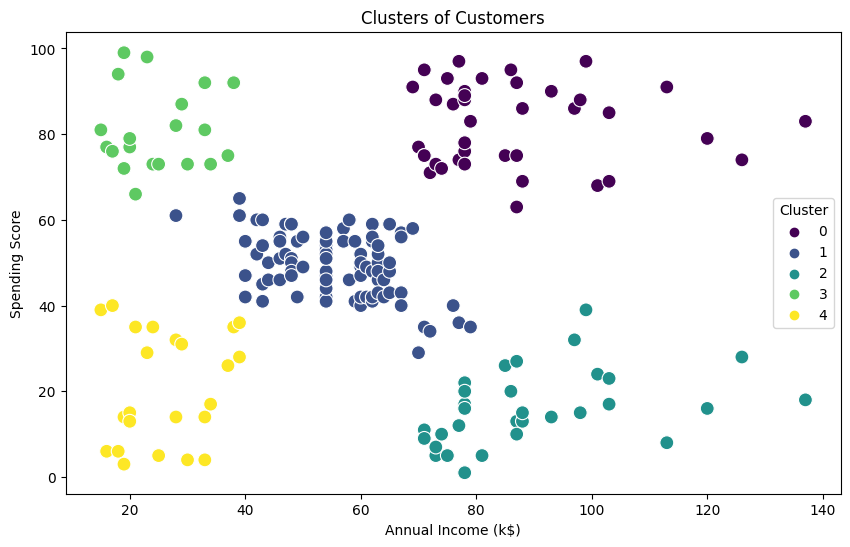

               Age  Annual_Income_(k$)  Spending_Score
Cluster                                               
0        32.692308           86.538462       82.128205
1        42.395349           55.488372       49.267442
2        41.000000           89.406250       15.593750
3        24.850000           24.950000       81.000000
4        45.217391           26.304348       20.913043


In [26]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/mall_customers.csv', index_col=0)

# Select the relevant features
X = data[['Annual_Income_(k$)', 'Spending_Score']]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Initialize the AgglomerativeClustering model
cluster = AgglomerativeClustering(n_clusters=5, linkage='ward')

# Fit the model and predict the cluster labels
labels = cluster.fit_predict(X_scaled)

# Add the cluster labels to the original data
data['Cluster'] = labels

# Create a scatter plot of the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['Annual_Income_(k$)'], y=data['Spending_Score'], hue=data['Cluster'], palette='viridis', s=100)
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.show()

# Calculate mean values of each numeric feature within each cluster
numeric_columns = ['Age', 'Annual_Income_(k$)', 'Spending_Score']
cluster_means = data.groupby('Cluster')[numeric_columns].mean()
print(cluster_means)


### Question 16

Which of the following practical interpretations best describes Cluster 2 based on the mean values of each feature generated in question 15?

#### Options:

* Customers in Cluster 2, on average, earn more annually compared to the average earnings of all customers in the dataset.

* Customers in Cluster 2, on average, have lower annual income compared to the average earnings of all customers in the dataset.

* Customers in Cluster 2, on average, spend more compared to the average spending habits of all customers in the dataset.

* Customers in Cluster 2, on average, spend more compared to all the customers in the dataset because they earn more annually.

### Question 17

In order to understand the distribution of data points among different clusters we can visualise the number of data points per cluster using a bar chart.

Generate a bar chart that displays the number of data points in each cluster for both our features. 

What inference can be drawn from the distribution of data points among clusters in our resulting clustering model?

#### Options:

* The clustering model has successfully separated the data into distinct and balanced clusters.

* The uneven distribution suggests potential issues with the clustering model's performance, such as overfitting.

* The clustering model demonstrates perfect separation of clusters, indicating robustness and accuracy.

* The imbalanced distribution suggests that the clustering algorithm requires more data to achieve better performance.

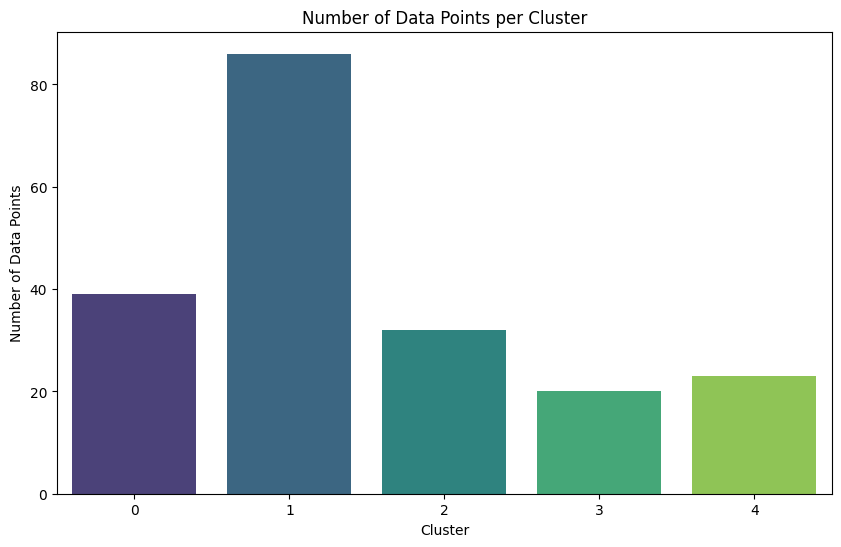

               Age  Annual_Income_(k$)  Spending_Score
Cluster                                               
0        32.692308           86.538462       82.128205
1        42.395349           55.488372       49.267442
2        41.000000           89.406250       15.593750
3        24.850000           24.950000       81.000000
4        45.217391           26.304348       20.913043


In [28]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/mall_customers.csv', index_col=0)

# Select the relevant features
X = data[['Annual_Income_(k$)', 'Spending_Score']]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Initialize the AgglomerativeClustering model
cluster = AgglomerativeClustering(n_clusters=5, linkage='ward')

# Fit the model and predict the cluster labels
labels = cluster.fit_predict(X_scaled)

# Add the cluster labels to the original data
data['Cluster'] = labels

# Generate a bar chart of the number of data points per cluster
plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', data=data, palette='viridis')
plt.title('Number of Data Points per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Data Points')
plt.show()

# Calculate mean values of each numeric feature within each cluster
numeric_columns = ['Age', 'Annual_Income_(k$)', 'Spending_Score']
cluster_means = data.groupby('Cluster')[numeric_columns].mean()
print(cluster_means)


### Question 18

When evaluating the quality of clustering using the `Davies-Bouldin Index (DBI)`, which of the following interpretations is correct?

#### Options:

* A lower DBI value indicates better clustering, where clusters are more compact and well-separated.
* A higher DBI value indicates better clustering, indicating more diverse and spread-out clusters.
* The DBI value does not provide any meaningful information about the clustering quality.
* The DBI value represents the average distance between all pairs of points in the dataset, with higher values indicating better clustering performance.

In [29]:
#Your code here
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score

# Load the dataset
data = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/mall_customers.csv', index_col=0)

# Select the relevant features
X = data[['Annual_Income_(k$)', 'Spending_Score']]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Initialize K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)

# Fit the model to the scaled data
kmeans.fit(X_scaled)

# Predict the clusters for the data points
clusters = kmeans.predict(X_scaled)

# Compute the Davies-Bouldin Index
dbi = davies_bouldin_score(X_scaled, clusters)
print(f'Davies-Bouldin Index: {dbi}')


Davies-Bouldin Index: 0.5616471225010365


### Question 19

Which linkage criterion measures the shortest distance between any two points in the two clusters being merged in hierarchical clustering?

#### Options
* Complete linkage
* Single linkage
* Average linkage
* Ward linkage

### Question 20

What is the best next step to take based on the silhouette scores for our KMeans clustering and Hierarchical clustering models, along with the distribution of data points in our clusters?

#### Options:

* Refit both clustering models with different hyperparameters.

* Perform further exploratory data analysis to understand the underlying patterns and potential reasons for the distribution of data points.

* Including additional relevant features to enrich the dataset and improve the clustering models' performance.

* All of the above

In [30]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# KMeans with different number of clusters
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    kmeans_labels = kmeans.predict(X_scaled)
    kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
    print(f'KMeans with {k} clusters: Silhouette Score = {kmeans_silhouette}')

# Agglomerative Clustering with different linkage methods
for linkage in ['ward', 'complete', 'average', 'single']:
    agglo = AgglomerativeClustering(n_clusters=5, linkage=linkage)
    agglo_labels = agglo.fit_predict(X_scaled)
    agglo_silhouette = silhouette_score(X_scaled, agglo_labels)
    print(f'Agglomerative Clustering with {linkage} linkage: Silhouette Score = {agglo_silhouette}')


KMeans with 2 clusters: Silhouette Score = 0.3447138642257591
KMeans with 3 clusters: Silhouette Score = 0.4498539603795658
KMeans with 4 clusters: Silhouette Score = 0.4971506623868143
KMeans with 5 clusters: Silhouette Score = 0.5593469429051445
KMeans with 6 clusters: Silhouette Score = 0.5244046259750482
KMeans with 7 clusters: Silhouette Score = 0.48083628842905113
KMeans with 8 clusters: Silhouette Score = 0.47423530152553683
KMeans with 9 clusters: Silhouette Score = 0.4332042575649034
KMeans with 10 clusters: Silhouette Score = 0.44833378088523645
Agglomerative Clustering with ward linkage: Silhouette Score = 0.5582698727196419
Agglomerative Clustering with complete linkage: Silhouette Score = 0.5418578306869118
Agglomerative Clustering with average linkage: Silhouette Score = 0.5565340544002426
Agglomerative Clustering with single linkage: Silhouette Score = 0.2716574259609395


              Age  Annual_Income_(k$)  Spending_Score     Cluster
count  200.000000          200.000000      200.000000  200.000000
mean    38.850000           60.560000       50.200000    1.510000
std     13.969007           26.264721       25.823522    1.239995
min     18.000000           15.000000        1.000000    0.000000
25%     28.750000           41.500000       34.750000    1.000000
50%     36.000000           61.500000       50.000000    1.000000
75%     49.000000           78.000000       73.000000    2.000000
max     70.000000          137.000000       99.000000    4.000000


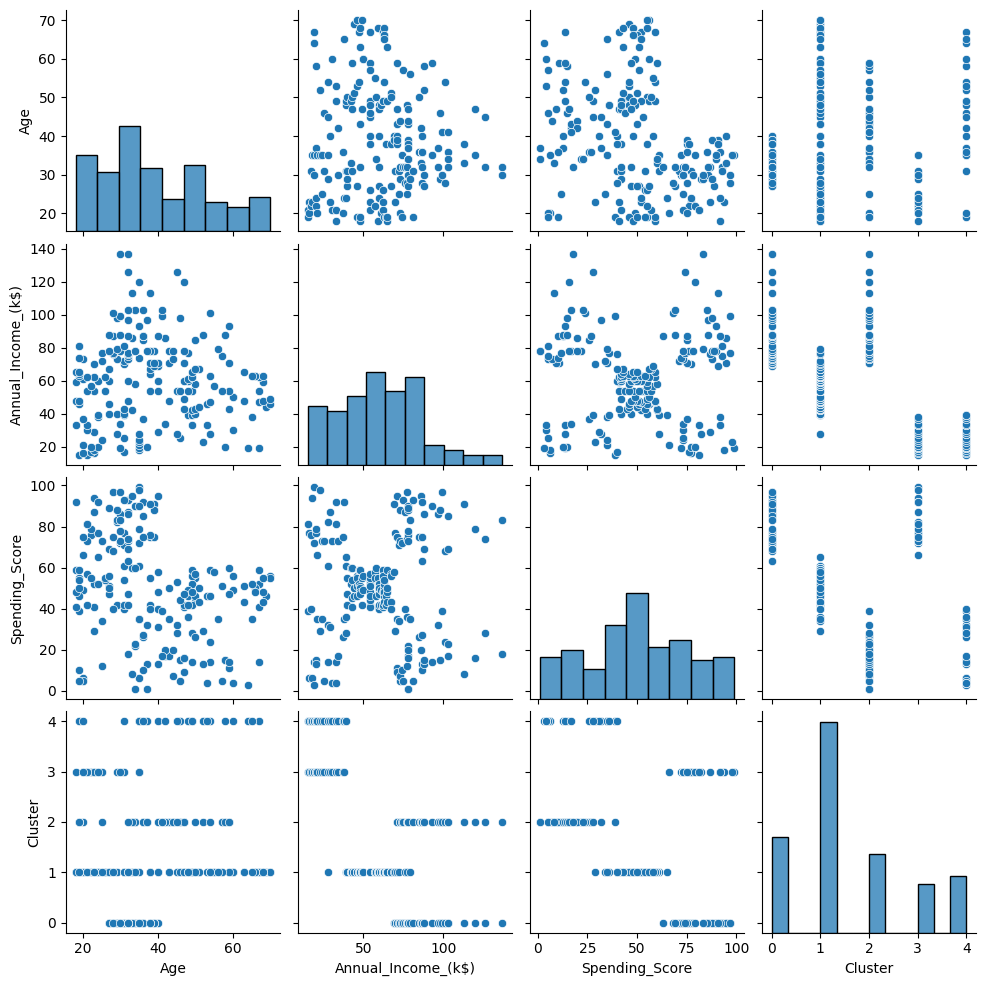

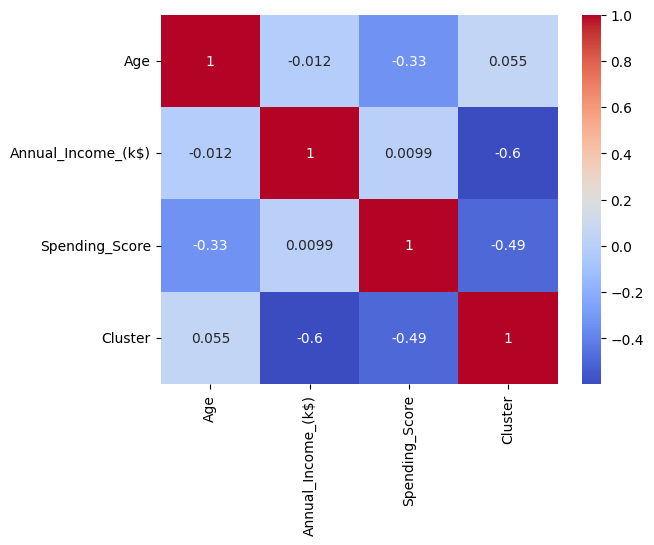

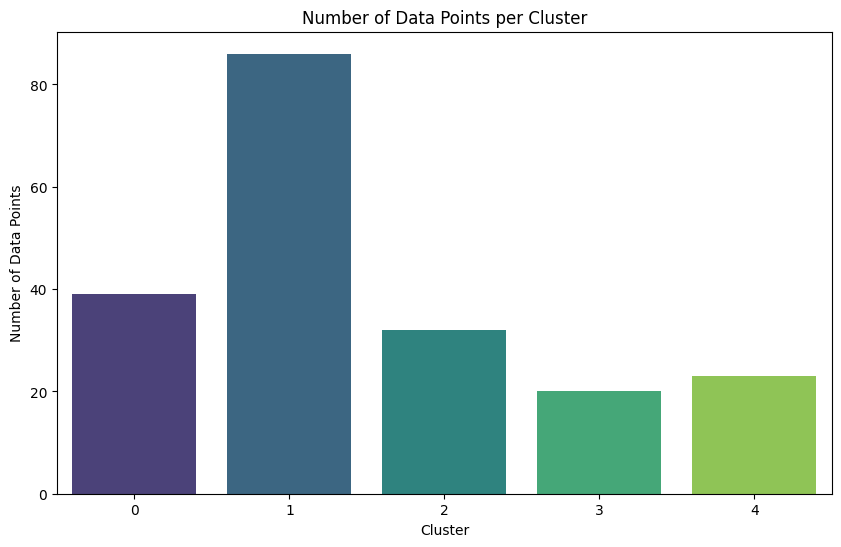

ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

In [34]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/mall_customers.csv', index_col=0)

# Select the relevant features
X = data[['Annual_Income_(k$)', 'Spending_Score']]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Initialize the AgglomerativeClustering model
cluster = AgglomerativeClustering(n_clusters=5, linkage='ward')

# Fit the model and predict the cluster labels
labels = cluster.fit_predict(X_scaled)

# Add the cluster labels to the original data
data['Cluster'] = labels

# Perform further EDA

# Statistical summaries
print(data.describe())

# Scatter plots for feature interactions
sns.pairplot(data.select_dtypes(include=['float64', 'int64']))  # Exclude non-numeric columns
plt.show()

# Correlation matrix
numeric_data = data.select_dtypes(include=['float64', 'int64'])  # Select only numeric columns
corr_matrix = numeric_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

# Generate a bar chart of the number of data points per cluster
plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', data=data, palette='viridis')
plt.title('Number of Data Points per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Data Points')
plt.show()

# Histograms of features
data.hist(figsize=(12, 10))
plt.show()

# Calculate mean values of each numeric feature within each cluster
numeric_columns = ['Age', 'Annual_Income_(k$)', 'Spending_Score']
cluster_means = data.groupby('Cluster')[numeric_columns].mean()
print(cluster_means)


#  

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/ExploreAI_logos/EAI_Blue_Dark.png"  style="width:200px";/>
</div>